# Factor Intensity Analysis

This notebook focuses on factor intensity rather than simple presence. It treats `9` as structured unknown data, uses only known scores (`0` to `3`) in intensity calculations, and keeps observation counts visible so thin evidence is easy to spot.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from config import COLLAPSE_DATASET_PATH
from dataset_utils import get_factor_columns, load_collapse_dataset

factor_categories = {
    "political": [
        "political_fragmentation",
        "elite_conflict",
        "succession_crisis",
        "legitimacy_crisis",
        "administrative_overload",
        "corruption_governance_failure",
    ],
    "social": [
        "social_inequality",
        "social_unrest_rebellion",
        "demographic_pressure",
        "migration_pressure",
        "ethnic_sectarian_fragmentation",
        "urban_decline",
    ],
    "economic": [
        "fiscal_crisis",
        "taxation_extraction_pressure",
        "trade_disruption",
        "inflation_currency_instability",
        "resource_dependency",
        "agricultural_decline",
    ],
    "environmental": [
        "drought_climate_stress",
        "flood_environmental_shock",
        "temperature_anomaly",
        "ecological_degradation",
        "food_insecurity",
    ],
    "military_geopolitical": [
        "external_invasion_pressure",
        "civil_war_internal_conflict",
        "military_overstretch",
        "territorial_loss",
    ],
    "resilience_institutional": [
        "institutional_rigidity",
        "adaptive_capacity",
        "logistics_food_storage_resilience",
        "alliance_network_strength",
        "recovery_capacity",
    ],
}

df = load_collapse_dataset(COLLAPSE_DATASET_PATH)
factor_cols = get_factor_columns()
factor_data = df[factor_cols].apply(pd.to_numeric, errors="coerce")
known_factor_data = factor_data.where(factor_data.isin([0, 1, 2, 3]))

collapse_mask = df["collapse_outcome"].eq(3)
severe_mask = df["collapse_outcome"].ge(2)

factor_to_category = {
    factor: category
    for category, columns in factor_categories.items()
    for factor in columns
}

df.shape

(174, 45)

## Factor Intensity Across The Dataset

These summaries compare average and median factor intensity across all known rows, then narrow to severe-decline/collapse rows and terminal-collapse rows.

In [3]:
factor_intensity = pd.DataFrame(
    {
        "category": pd.Series(factor_to_category),
        "known_n_all": known_factor_data.notna().sum(),
        "mean_all_known": known_factor_data.mean(),
        "median_all_known": known_factor_data.median(),
        "known_n_outcome_3": known_factor_data.loc[collapse_mask].notna().sum(),
        "mean_outcome_3": known_factor_data.loc[collapse_mask].mean(),
        "known_n_outcome_ge_2": known_factor_data.loc[severe_mask].notna().sum(),
        "mean_outcome_ge_2": known_factor_data.loc[severe_mask].mean(),
    }
)
factor_intensity = factor_intensity.sort_values(["mean_all_known", "known_n_all"], ascending=[False, False])
display(factor_intensity.round(3))

,category,known_n_all,mean_all_known,median_all_known,known_n_outcome_3,mean_outcome_3,known_n_outcome_ge_2,mean_outcome_ge_2
recovery_capacity,resilience_institutional,174,1.983,2.0,23,1.087,80,1.325
corruption_governance_failure,political,58,1.983,2.0,14,2.071,51,2.039
adaptive_capacity,resilience_institutional,174,1.914,2.0,23,1.043,80,1.225
administrative_overload,political,147,1.884,2.0,21,2.619,68,2.235
resource_dependency,economic,173,1.861,2.0,23,1.957,79,2.051
elite_conflict,political,147,1.837,2.0,21,2.524,68,2.250
logistics_food_storage_resilience,resilience_institutional,174,1.787,2.0,23,1.043,80,1.125
institutional_rigidity,resilience_institutional,174,1.782,2.0,23,2.609,80,2.175
social_inequality,social,109,1.771,2.0,14,2.000,60,1.900
military_overstretch,military_geopolitical,166,1.711,2.0,21,2.571,73,2.205


## Ranked Factors By Overall Mean Intensity

,category,known_n_all,mean_all_known,median_all_known,known_n_outcome_ge_2,mean_outcome_ge_2,known_n_outcome_3,mean_outcome_3
recovery_capacity,resilience_institutional,174,1.983,2.0,80,1.325,23,1.087
corruption_governance_failure,political,58,1.983,2.0,51,2.039,14,2.071
adaptive_capacity,resilience_institutional,174,1.914,2.0,80,1.225,23,1.043
administrative_overload,political,147,1.884,2.0,68,2.235,21,2.619
resource_dependency,economic,173,1.861,2.0,79,2.051,23,1.957
elite_conflict,political,147,1.837,2.0,68,2.250,21,2.524
logistics_food_storage_resilience,resilience_institutional,174,1.787,2.0,80,1.125,23,1.043
institutional_rigidity,resilience_institutional,174,1.782,2.0,80,2.175,23,2.609
social_inequality,social,109,1.771,2.0,60,1.900,14,2.000
military_overstretch,military_geopolitical,166,1.711,2.0,73,2.205,21,2.571


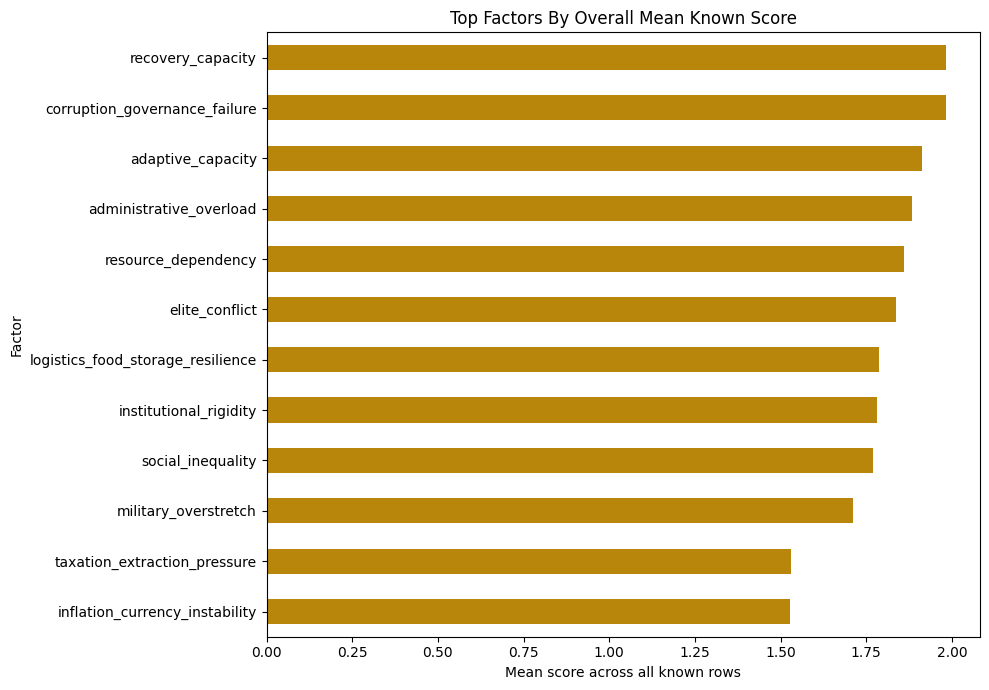

In [4]:
ranked_factors = factor_intensity[[
    "category",
    "known_n_all",
    "mean_all_known",
    "median_all_known",
    "known_n_outcome_ge_2",
    "mean_outcome_ge_2",
    "known_n_outcome_3",
    "mean_outcome_3",
]].copy()
display(ranked_factors.round(3))

top_overall = ranked_factors.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
top_overall["mean_all_known"].plot(kind="barh", ax=ax, color="darkgoldenrod")
ax.set_title("Top Factors By Overall Mean Known Score")
ax.set_xlabel("Mean score across all known rows")
ax.set_ylabel("Factor")
plt.tight_layout()
plt.show()

## Case-Level Average Known Scores By Factor

This table shows the average known score for each factor within each case. Counts are shown separately so lower-data comparisons stay visible.

In [5]:
case_factor_mean = known_factor_data.groupby(df["case_name"]).mean().round(2)
case_factor_known_n = known_factor_data.notna().groupby(df["case_name"]).sum().astype(int)

display(case_factor_mean)
display(case_factor_known_n)

,political_fragmentation,elite_conflict,succession_crisis,legitimacy_crisis,administrative_overload,corruption_governance_failure,social_inequality,social_unrest_rebellion,demographic_pressure,migration_pressure,ethnic_sectarian_fragmentation,urban_decline,fiscal_crisis,taxation_extraction_pressure,trade_disruption,inflation_currency_instability,resource_dependency,agricultural_decline,drought_climate_stress,flood_environmental_shock,temperature_anomaly,ecological_degradation,food_insecurity,external_invasion_pressure,civil_war_internal_conflict,military_overstretch,territorial_loss,institutional_rigidity,adaptive_capacity,logistics_food_storage_resilience,alliance_network_strength,recovery_capacity
case_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Akkadian Empire,1.50,1.75,1.38,1.25,1.88,2.00,2.00,1.12,NaN,1.50,NaN,1.38,1.38,1.71,1.25,NaN,2.50,1.40,1.67,NaN,NaN,1.00,1.12,1.75,1.38,2.62,1.50,1.75,1.75,1.75,1.50,1.88
Aztec Empire,1.00,1.60,1.40,1.00,1.80,2.00,1.60,1.00,NaN,2.00,NaN,1.00,1.00,1.60,0.80,NaN,1.60,1.33,NaN,NaN,NaN,NaN,1.00,1.80,0.60,1.80,1.00,1.80,2.20,2.20,1.00,2.20
Bronze Age Collapse States,1.75,1.60,NaN,1.00,2.00,NaN,NaN,0.60,NaN,2.00,NaN,1.50,0.50,NaN,2.12,NaN,1.62,1.33,1.67,NaN,NaN,NaN,1.00,1.80,1.00,2.00,1.50,2.12,1.38,1.38,1.25,1.50
Byzantine Decline,1.68,2.21,1.95,1.68,2.05,2.00,2.00,1.68,NaN,1.44,NaN,1.89,1.89,1.94,1.84,2.00,1.84,1.12,NaN,NaN,NaN,NaN,1.68,2.37,1.84,2.26,2.26,2.21,1.53,1.21,1.16,1.53
Classic Mesopotamian States,2.05,1.94,1.73,1.28,2.06,2.00,2.00,1.22,NaN,1.14,NaN,1.25,1.28,1.73,1.35,NaN,1.85,1.06,2.00,NaN,NaN,NaN,1.20,1.83,1.22,1.94,1.35,1.90,1.80,1.70,1.20,1.80
Easter Island,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,1.0,0.30,0.00,0.00,NaN,NaN,0.00,NaN,2.50,0.80,2.00,NaN,NaN,2.00,0.80,0.00,NaN,0.00,0.00,1.00,2.70,2.00,NaN,2.50
Han Dynasty Crisis,2.14,2.29,1.71,2.00,2.29,2.33,2.00,1.57,NaN,1.60,NaN,1.86,2.29,2.00,1.71,NaN,1.71,1.20,1.00,1.00,NaN,NaN,1.29,2.14,2.00,2.29,2.14,2.29,1.29,1.29,1.29,1.29
Inca Empire,1.00,1.57,1.29,0.86,1.57,2.00,2.00,1.14,NaN,2.00,NaN,0.86,0.86,1.33,0.71,NaN,1.29,1.50,NaN,NaN,NaN,NaN,0.57,1.43,0.71,1.43,1.00,1.57,2.29,2.29,1.71,2.29
Khmer Empire,1.17,1.61,1.39,1.11,1.67,2.00,2.00,1.00,NaN,1.25,NaN,1.11,1.11,1.59,1.00,NaN,2.00,1.10,1.50,2.25,NaN,1.25,1.00,1.50,1.00,1.67,1.00,1.67,1.94,1.94,1.56,2.00


,political_fragmentation,elite_conflict,succession_crisis,legitimacy_crisis,administrative_overload,corruption_governance_failure,social_inequality,social_unrest_rebellion,demographic_pressure,migration_pressure,ethnic_sectarian_fragmentation,urban_decline,fiscal_crisis,taxation_extraction_pressure,trade_disruption,inflation_currency_instability,resource_dependency,agricultural_decline,drought_climate_stress,flood_environmental_shock,temperature_anomaly,ecological_degradation,food_insecurity,external_invasion_pressure,civil_war_internal_conflict,military_overstretch,territorial_loss,institutional_rigidity,adaptive_capacity,logistics_food_storage_resilience,alliance_network_strength,recovery_capacity
case_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Akkadian Empire,8,8,8,8,8,3,3,8,0,4,0,8,8,7,8,0,8,5,3,0,0,2,8,8,8,8,8,8,8,8,8,8
Aztec Empire,5,5,5,5,5,1,5,5,0,1,0,5,5,5,5,0,5,3,0,0,0,0,5,5,5,5,5,5,5,5,5,5
Bronze Age Collapse States,8,5,0,5,5,0,0,5,0,3,0,8,4,0,8,0,8,6,3,0,0,0,8,5,4,5,8,8,8,8,8,8
Byzantine Decline,19,19,19,19,19,14,14,19,0,16,0,19,19,17,19,3,19,16,0,0,0,0,19,19,19,19,19,19,19,19,19,19
Classic Mesopotamian States,20,18,11,18,18,7,7,18,0,7,0,20,18,11,20,0,20,17,1,0,0,0,20,18,18,18,20,20,20,20,20,20
Easter Island,0,0,0,0,0,0,20,0,20,20,20,20,0,0,20,0,20,20,6,0,0,20,20,20,0,20,20,20,20,20,0,20
Han Dynasty Crisis,7,7,7,7,7,3,5,7,0,5,0,7,7,5,7,0,7,5,1,1,0,0,7,7,7,7,7,7,7,7,7,7
Inca Empire,7,7,7,7,7,1,1,7,0,2,0,7,7,6,7,0,7,2,0,0,0,0,7,7,7,7,7,7,7,7,7,7
Khmer Empire,18,18,18,18,18,7,7,18,0,8,0,18,18,17,18,0,18,10,6,4,0,4,18,18,18,18,18,18,18,18,18,18


## Case-Level Average Known Scores By Category

Category means below average only known values within each case-category block, and the companion count table shows how many factor observations support each cell.

,political,social,economic,environmental,military_geopolitical,resilience_institutional
Akkadian Empire,1.58,1.39,1.67,1.23,1.81,1.72
Aztec Empire,1.38,1.25,1.26,1.00,1.30,1.88
Bronze Age Collapse States,1.61,1.31,1.54,1.18,1.59,1.52
Byzantine Decline,1.93,1.75,1.75,1.68,2.18,1.53
Classic Mesopotamian States,1.84,1.33,1.44,1.24,1.58,1.68
Easter Island,NaN,0.46,1.10,1.48,0.00,2.05
Han Dynasty Crisis,2.11,1.75,1.81,1.22,2.14,1.49
Inca Empire,1.28,1.18,1.07,0.57,1.14,2.03
Khmer Empire,1.43,1.22,1.38,1.28,1.29,1.82
Maya,1.46,1.33,1.49,1.32,1.47,1.60


,political,social,economic,environmental,military_geopolitical,resilience_institutional
Akkadian Empire,43,23,36,13,32,40
Aztec Empire,26,16,23,5,20,25
Bronze Age Collapse States,23,16,26,11,22,40
Byzantine Decline,109,68,93,19,76,95
Classic Mesopotamian States,92,52,86,21,74,100
Easter Island,0,100,60,46,60,80
Han Dynasty Crisis,38,24,31,9,28,35
Inca Empire,36,17,29,7,28,35
Khmer Empire,97,51,81,32,72,90
Maya,50,51,49,22,45,70


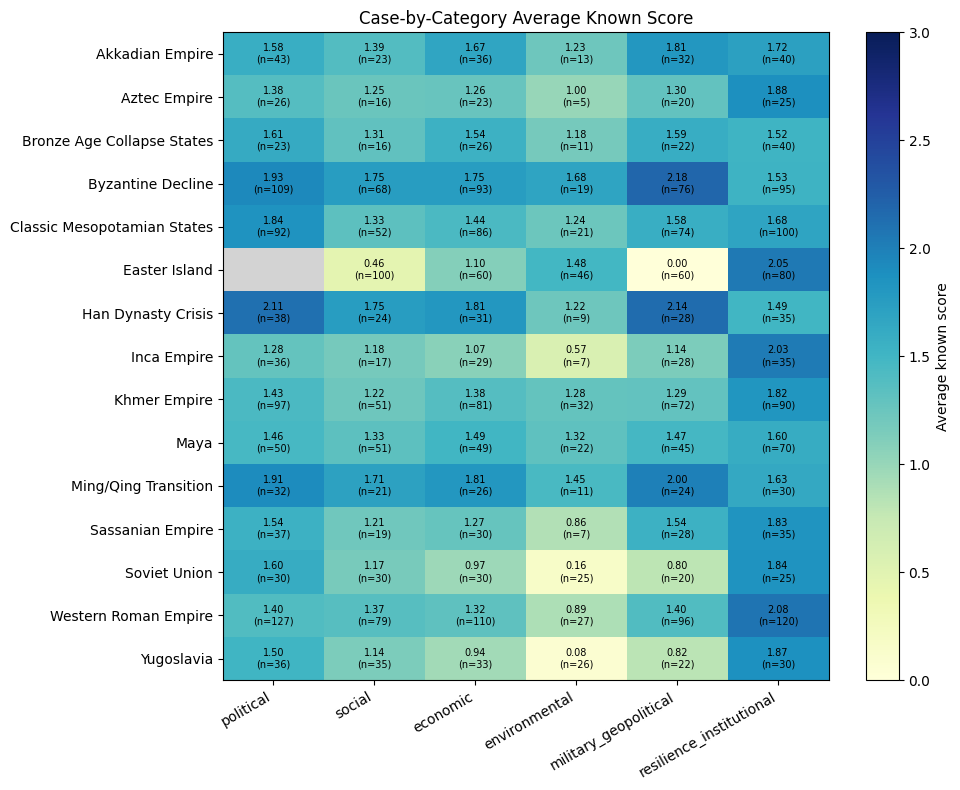

In [6]:
case_category_mean = pd.DataFrame(index=sorted(df["case_name"].unique()))
case_category_known_n = pd.DataFrame(index=sorted(df["case_name"].unique()))

for category, columns in factor_categories.items():
    case_category_mean[category] = known_factor_data[columns].groupby(df["case_name"]).apply(lambda frame: frame.stack().mean())
    case_category_known_n[category] = known_factor_data[columns].notna().groupby(df["case_name"]).sum().sum(axis=1)

case_category_mean = case_category_mean.round(2)
case_category_known_n = case_category_known_n.astype(int)

display(case_category_mean)
display(case_category_known_n)

matrix = np.ma.masked_invalid(case_category_mean.to_numpy())
cmap = plt.cm.YlGnBu.copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=3)
ax.set_xticks(range(len(case_category_mean.columns)))
ax.set_xticklabels(case_category_mean.columns, rotation=30, ha="right")
ax.set_yticks(range(len(case_category_mean.index)))
ax.set_yticklabels(case_category_mean.index)
ax.set_title("Case-by-Category Average Known Score")

for row_idx, case_name in enumerate(case_category_mean.index):
    for col_idx, category in enumerate(case_category_mean.columns):
        value = case_category_mean.loc[case_name, category]
        count = case_category_known_n.loc[case_name, category]
        if pd.notna(value):
            ax.text(col_idx, row_idx, f"{value:.2f}\n(n={count})", ha="center", va="center", fontsize=7)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Average known score")
plt.tight_layout()
plt.show()

## Top Factors In Terminal-Collapse Rows

This table isolates rows with `collapse_outcome = 3` to show which factors are most intense in terminal-collapse conditions, alongside the number of known terminal observations for each factor.

,category,known_n_outcome_3,mean_outcome_3,known_n_all,mean_all_known
political_fragmentation,political,23,3.000,154,1.468
ethnic_sectarian_fragmentation,social,2,3.000,31,0.645
territorial_loss,military_geopolitical,23,2.913,174,1.213
fiscal_crisis,economic,19,2.737,145,1.297
inflation_currency_instability,economic,3,2.667,19,1.526
administrative_overload,political,21,2.619,147,1.884
legitimacy_crisis,political,21,2.619,147,1.279
institutional_rigidity,resilience_institutional,23,2.609,174,1.782
urban_decline,social,23,2.609,174,1.138
military_overstretch,military_geopolitical,21,2.571,166,1.711


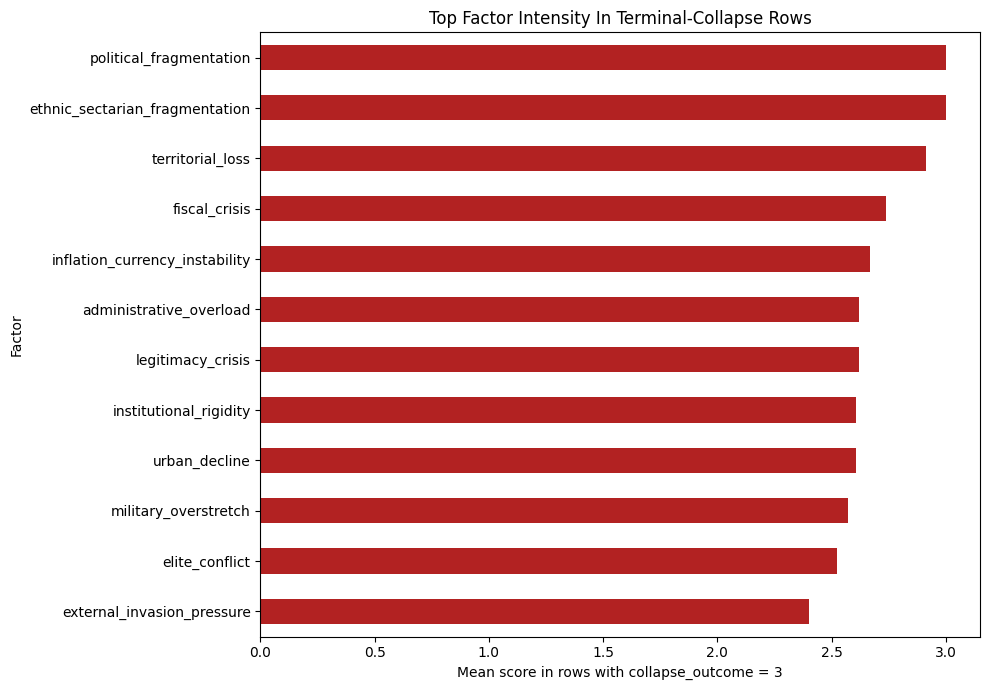

In [7]:
terminal_factor_table = factor_intensity[["category", "known_n_outcome_3", "mean_outcome_3", "known_n_all", "mean_all_known"]].copy()
terminal_factor_table = terminal_factor_table.sort_values(["mean_outcome_3", "known_n_outcome_3"], ascending=[False, False])
display(terminal_factor_table.round(3))

top_terminal = terminal_factor_table.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
top_terminal["mean_outcome_3"].plot(kind="barh", ax=ax, color="firebrick")
ax.set_title("Top Factor Intensity In Terminal-Collapse Rows")
ax.set_xlabel("Mean score in rows with collapse_outcome = 3")
ax.set_ylabel("Factor")
plt.tight_layout()
plt.show()

## Short Interpretation

These summaries help distinguish factors that are frequently present from factors that tend to be scored at high intensity when they are known. High mean intensity with a low observation count should be treated cautiously, especially for debated or sparsely coded factors.

In [8]:
top_all = factor_intensity.head(5).index.tolist()
top_terminal = terminal_factor_table.head(5).index.tolist()
high_data_factors = factor_intensity.sort_values(["known_n_all", "mean_all_known"], ascending=[False, False]).head(5).index.tolist()

summary_md = f"""
### Interpretation Notes

- The highest overall mean intensities across known rows appear in **{', '.join(top_all)}**.
- In terminal-collapse rows, the strongest intensities appear in **{', '.join(top_terminal)}**.
- The best-supported factors by observation count are **{', '.join(high_data_factors)}**, which helps separate robust patterns from thinner signals.
- Use the count columns alongside the mean and median values: a high score based on only a handful of known rows should not be read as equally secure as a high score with broad coverage.
"""

display(Markdown(summary_md))


### Interpretation Notes

- The highest overall mean intensities across known rows appear in **recovery_capacity, corruption_governance_failure, adaptive_capacity, administrative_overload, resource_dependency**.
- In terminal-collapse rows, the strongest intensities appear in **political_fragmentation, ethnic_sectarian_fragmentation, territorial_loss, fiscal_crisis, inflation_currency_instability**.
- The best-supported factors by observation count are **recovery_capacity, adaptive_capacity, logistics_food_storage_resilience, institutional_rigidity, territorial_loss**, which helps separate robust patterns from thinner signals.
- Use the count columns alongside the mean and median values: a high score based on only a handful of known rows should not be read as equally secure as a high score with broad coverage.
